# does log(log(death/birth)) track the point process params? (nested Thomas)

Same check as `loglog_death_birth_vs_params.ipynb`, run on the nested Thomas
diagrams instead of Matern. This process has 5 swept params (not 2):
`parent_intensity`, `meta_offspring`, `meta_cluster_scale` (outer/meta cluster
process) and `mean_offspring`, `cluster_scale` (inner cluster process) --
`edge_buffer` also sits in `generator_params` but it's derived, not an
independent sweep target, so it's left out.

Per (diagram, dim) row: nine summary statistics of log(log(death/birth)) over
finite H0/H1 pairs -- `mean`, `median`, `min`, `max`, `std`, `variance`, `iqr`
(75th - 25th percentile), `skew`, `kurtosis` -- each correlated (Pearson, on
`log(param)`) against every swept param. A dedicated sanity-check cell right
after the per-diagram computation re-derives the invariants the transform
relies on (birth > 0, ratio > 1 so `log(log(ratio))` is real) directly from
this run's sample instead of assuming them, and every correlation below is
NaN-masked so a handful of degenerate low-pair diagrams (mostly H1, which can
have as few as 0-2 finite pairs) can't silently corrupt a Pearson r computed
over the rest.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, skew, kurtosis

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cloudforger.core.records import load_diagrams

OUT = ROOT / "notebooks" / "out"
OUT.mkdir(parents=True, exist_ok=True)

In [ ]:
diagrams, _bundle = load_diagrams(ROOT / "data" / "nested_thomas" / "dtm_k10" / "diagrams.pkl")
print(f"{len(diagrams)} diagrams available")

PARAMS = ["parent_intensity", "meta_offspring", "meta_cluster_scale", "mean_offspring", "cluster_scale"]

N_SAMPLE = min(600, len(diagrams))  # robust to a partial/in-progress diagrams.pkl
rng = np.random.default_rng(0)
sample = [diagrams[i] for i in rng.choice(len(diagrams), size=N_SAMPLE, replace=False)]

In [ ]:
# Nine summary statistics of the per-pair log(log(death/birth)) distribution,
# computed the same way for every (diagram, dim): mean/median/min/max locate
# it, std/variance/iqr spread it, skew/kurtosis shape it. All population
# (ddof=0 / bias=True) statistics, matching np.std's default used before.
STATS = {
    "mean": np.mean,
    "median": np.median,
    "min": np.min,
    "max": np.max,
    "std": np.std,
    "variance": np.var,
    "iqr": lambda a: np.percentile(a, 75) - np.percentile(a, 25),
    "skew": skew,
    "kurtosis": kurtosis,
}

rows = []
n_dropped_pairs = 0  # pairs with ratio <= 1 or birth <= 0 -> log(log(ratio)) non-finite
for d in sample:
    for dim in (0, 1):
        pairs = d.finite_pairs(dim)  # drops the one infinite-death H0 class
        if len(pairs) == 0:
            continue
        ratio = pairs[:, 1] / pairs[:, 0]
        with np.errstate(divide="ignore", invalid="ignore"):
            loglog = np.log(np.log(ratio))  # ratio > 1 always in practice -> log(ratio) > 0
        finite = np.isfinite(loglog)
        n_dropped_pairs += int((~finite).sum())
        loglog = loglog[finite]
        if len(loglog) == 0:
            continue
        row = {"dim": dim, "n_pairs": len(loglog)}
        with np.errstate(invalid="ignore"):  # skew/kurtosis of a 1-pair diagram is 0/0 -> nan by design
            for name, fn in STATS.items():
                row[f"{name}_loglog"] = float(fn(loglog))
        for p in PARAMS:
            row[p] = d.generator_params[p]
        rows.append(row)


def col(name):
    return np.array([r[name] for r in rows], dtype=float)


dim_arr = col("dim")
print(f"{len(rows)} (diagram, dim) rows")
if n_dropped_pairs:
    print(f"dropped {n_dropped_pairs} individual pairs with ratio <= 1 or birth <= 0 "
          "(log(log(ratio)) undefined for those) -- see the sanity-check cell below")

In [ ]:
MIN_N_FOR_CORR = 10  # below this many finite (x, y) pairs, Pearson r is too noisy to report


def safe_pearsonr(x, y):
    """Pearson r over the rows where both x and y are finite, dropping NaNs
    from degenerate low-pair diagrams instead of letting them poison the
    whole coefficient (scipy.stats.pearsonr does not do this itself)."""
    mask = np.isfinite(x) & np.isfinite(y)
    n = int(mask.sum())
    if n < MIN_N_FOR_CORR:
        return np.nan, n
    r, _p = pearsonr(x[mask], y[mask])
    return r, n


print(f"{'dim':>3} {'stat':>10} {'param':>18} {'pearson r (log param)':>22} {'n':>6}")
for dim in (0, 1):
    mask = dim_arr == dim
    for stat in STATS:
        y = col(f"{stat}_loglog")[mask]
        for param in PARAMS:
            x = np.log(col(param)[mask])
            r, n = safe_pearsonr(x, y)
            print(f"{dim:>3} {stat:>10} {param:>18} {r:>22.3f} {n:>6}")

## Figure 1 -- mean log(log(death/birth)) per diagram

Bulk behavior, sensitive to the tail (an outlier feature pulls the mean with
it, unlike the median below).

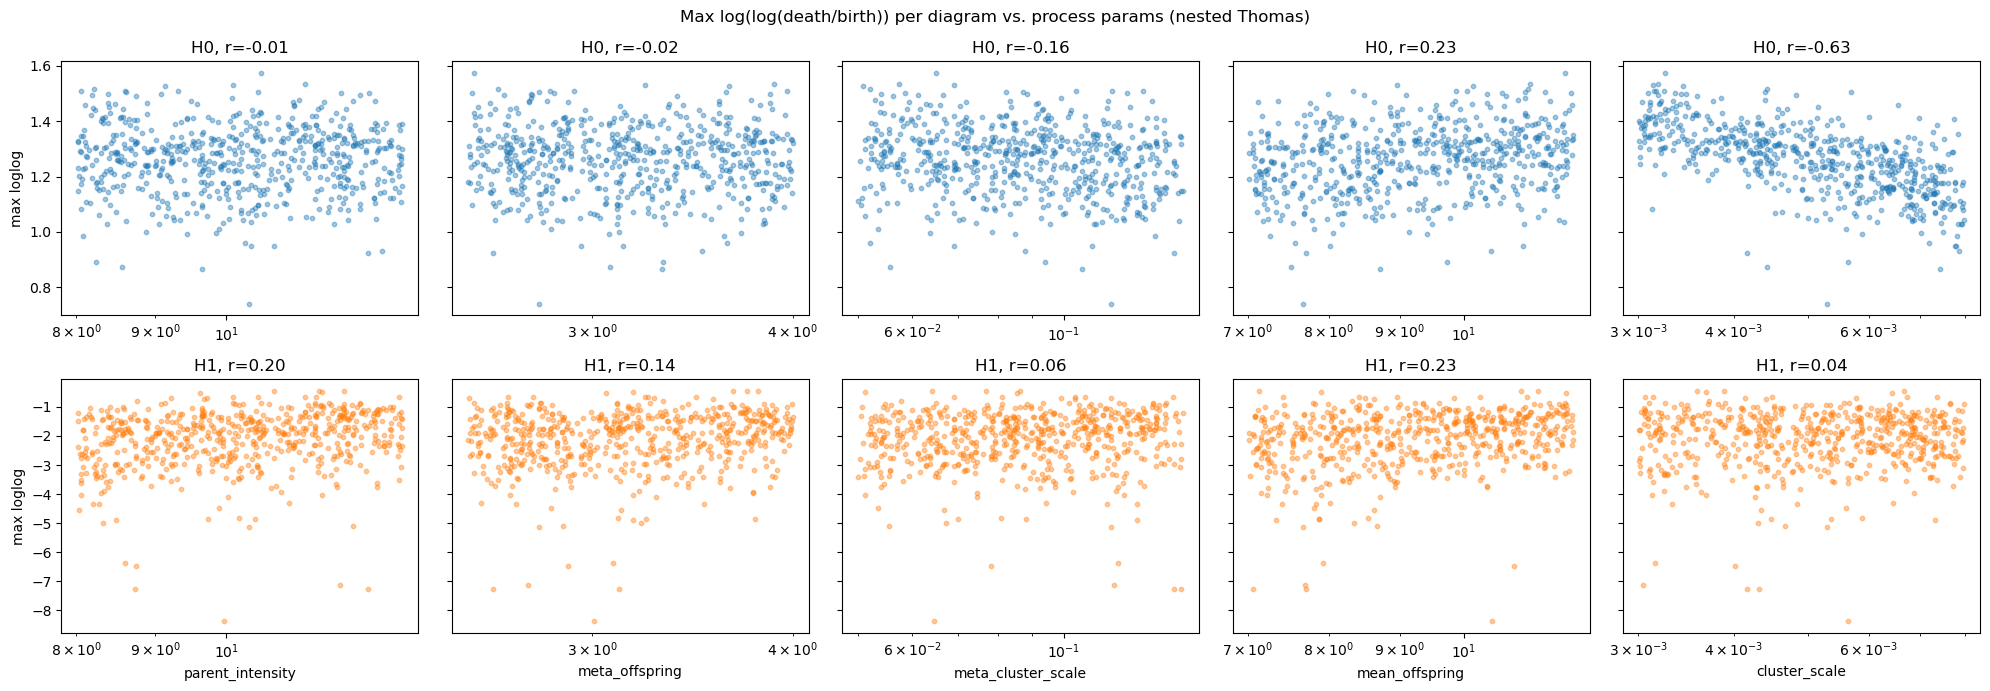

In [13]:
def plot_grid(stat, title, fname):
    fig, axes = plt.subplots(2, len(PARAMS), figsize=(4 * len(PARAMS), 7), sharey="row")
    colors = {0: "tab:blue", 1: "tab:orange"}
    for row, dim in enumerate((0, 1)):
        mask = dim_arr == dim
        y = col(stat)[mask]
        for c, param in enumerate(PARAMS):
            ax = axes[row, c]
            x = col(param)[mask]
            r, _p = pearsonr(np.log(x), y)
            ax.scatter(x, y, s=10, alpha=0.4, color=colors[dim])
            ax.set_xscale("log")
            ax.set_title(f"H{dim}, r={r:.2f}")
            if row == 1:
                ax.set_xlabel(param)
            if c == 0:
                ax.set_ylabel(f"{stat.replace('_', ' ')}")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUT / fname, dpi=150)
    plt.show()


plot_grid("max_loglog", "Max log(log(death/birth)) per diagram vs. process params (nested Thomas)",
           "11_loglog_ratio_max_vs_params_nested_thomas.png")

## Figure 2 -- median log(log(death/birth)) per diagram

Bulk behavior instead of just the top feature.

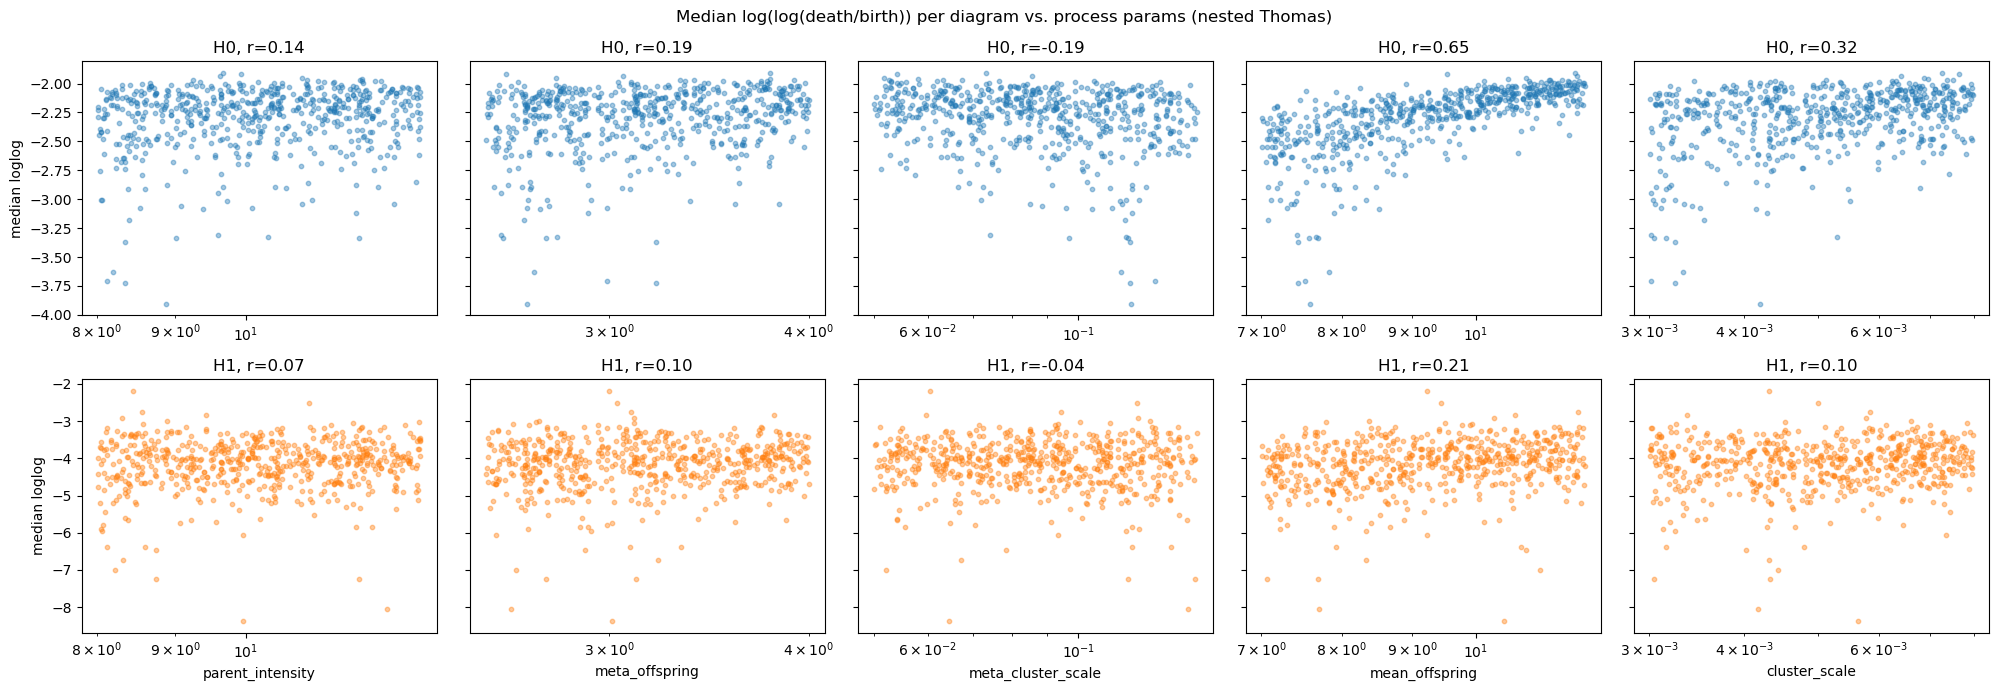

In [14]:
plot_grid("median_loglog", "Median log(log(death/birth)) per diagram vs. process params (nested Thomas)",
           "12_loglog_ratio_median_vs_params_nested_thomas.png")

## Figure 3 -- mean log(log(death/birth)) per diagram

Bulk behavior again, but mean instead of median (sensitive to the tail rather
than robust to it).

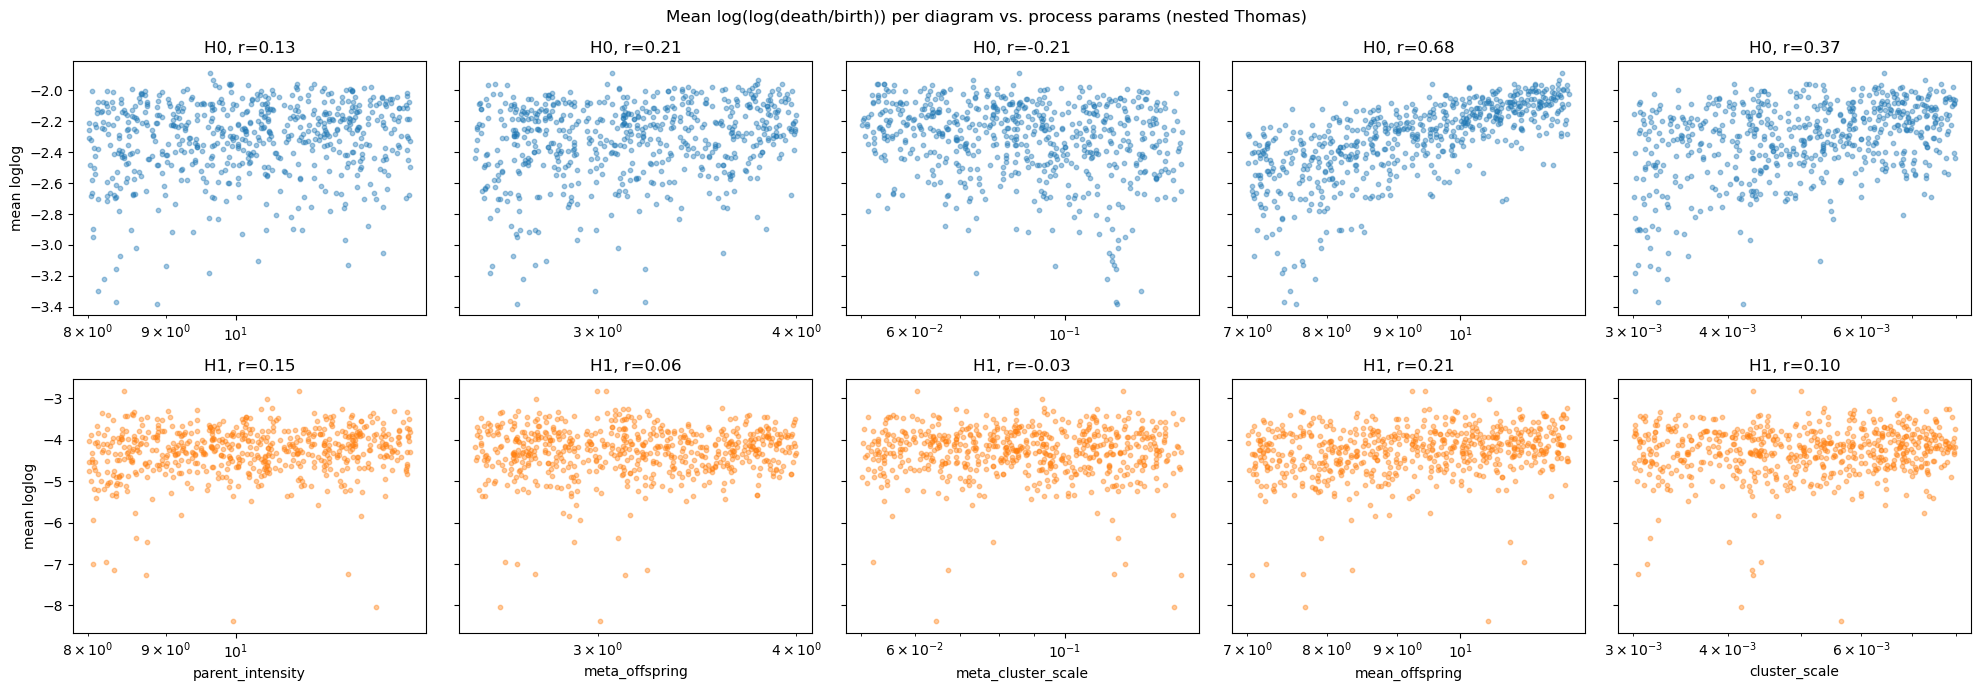

In [15]:
plot_grid("mean_loglog", "Mean log(log(death/birth)) per diagram vs. process params (nested Thomas)",
           "13_loglog_ratio_mean_vs_params_nested_thomas.png")

## Figure 4 -- std log(log(death/birth)) per diagram

Bulk behavior again, but mean instead of median (sensitive to the tail rather
than robust to it).

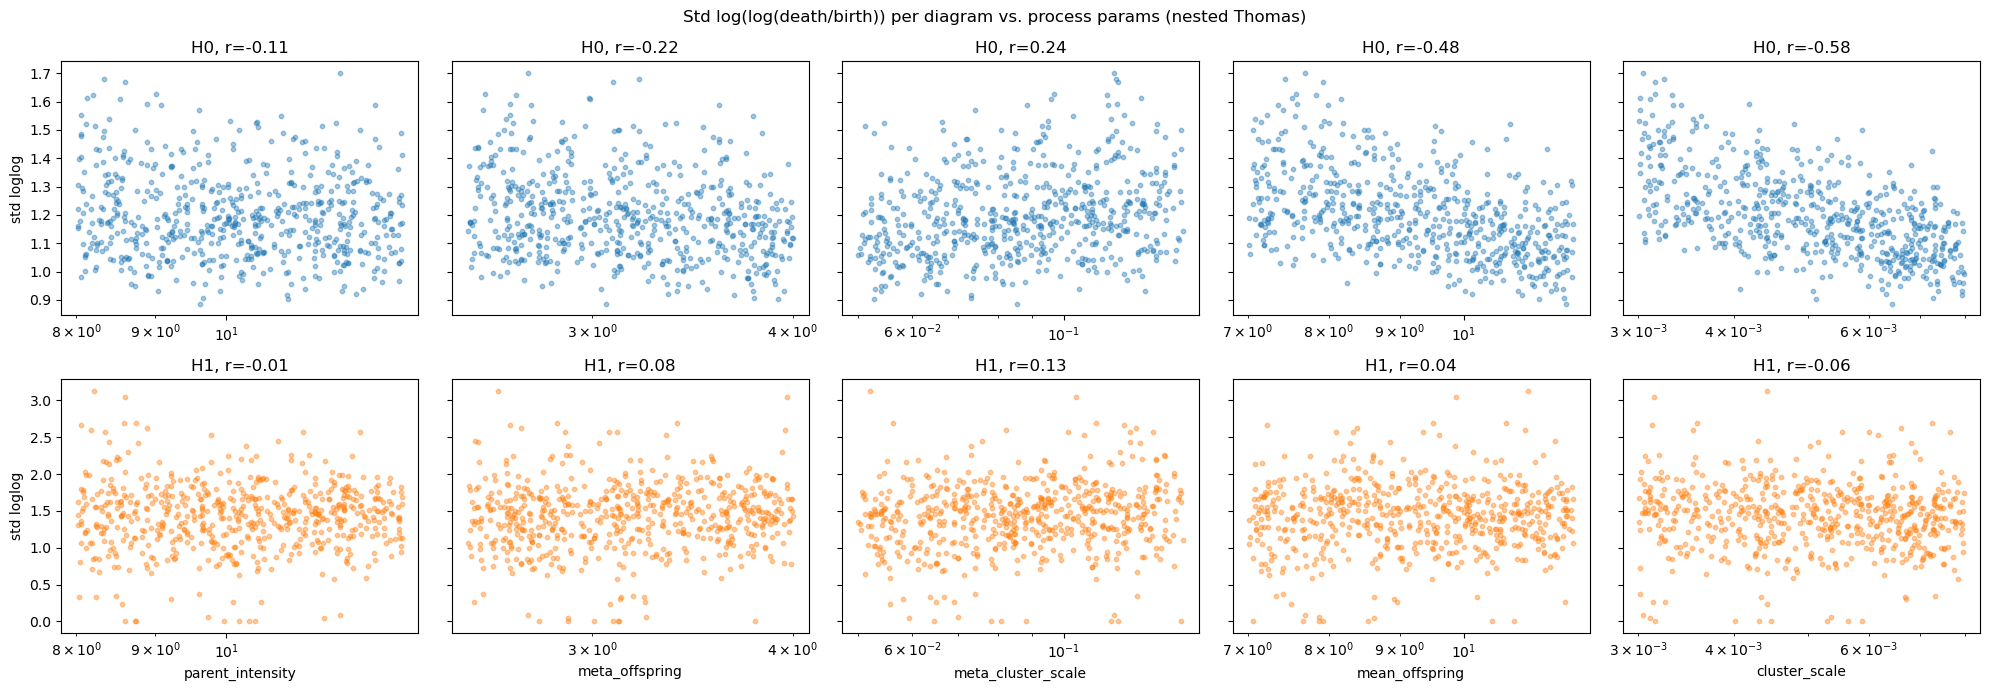

In [16]:
plot_grid("std_loglog", "Std log(log(death/birth)) per diagram vs. process params (nested Thomas)",
           "13_loglog_ratio_std_vs_params_nested_thomas.png")